2024-03-30 23:16:12.238913: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-03-30 23:16:12.270893: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-03-30 23:16:12.812122: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.3
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


Train: X=(60000, 28, 28), y=(60000,)
Test: X=(10000, 28, 28), y=(10000,)


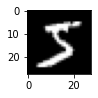

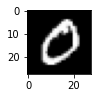

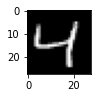

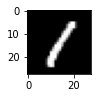

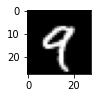

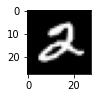

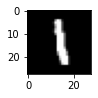

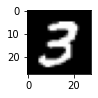

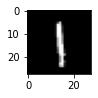

In [1]:
from tensorflow.keras.datasets import mnist
from matplotlib import pyplot as plt

# load dataset
(trainX, trainy), (testX, testy) = mnist.load_data()

# summarize loaded dataset
print('Train: X=%s, y=%s' % (trainX.shape, trainy.shape))
print('Test: X=%s, y=%s' % (testX.shape, testy.shape))

# plot first few images
for i in range(9):
  # define subplot
  plt.subplot(330 + 1 + i)
  # plot raw pixel data
  plt.imshow(trainX[i], cmap=plt.get_cmap('gray'))
  # show the figure
  plt.show()

In [2]:
from numpy import mean
from numpy import std
from matplotlib import pyplot as plt
from sklearn.model_selection import KFold
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Flatten
from tensorflow.keras.optimizers import SGD
from numpy import argmax
from keras.preprocessing.image import load_img
from keras.preprocessing.image import img_to_array
from keras.models import load_model

In [3]:
def load_dataset():
  # load dataset
  (trainX, trainY), (testX, testY) = mnist.load_data()

  # reshape dataset to have a single channel
  trainX = trainX.reshape((trainX.shape[0], 28, 28, 1))
  testX = testX.reshape((testX.shape[0], 28, 28, 1))

  # one hot encode target values
  trainY = to_categorical(trainY)
  testY = to_categorical(testY)
  return trainX, trainY, testX, testY

In [4]:
def prep_pixels(train, test):
  # convert from integers to floats
  train_norm = train.astype('float32')
  test_norm = test.astype('float32')

  # normalize to range 0-1
  train_norm = train_norm / 255.0
  test_norm = test_norm / 255.0

  # return normalized images
  return train_norm, test_norm

In [5]:
def define_model():
  model = Sequential()
  model.add(Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_uniform', input_shape=(28, 28, 1)))
  model.add(MaxPooling2D((2, 2)))
  model.add(Flatten())
  model.add(Dense(100, activation='relu', kernel_initializer='he_uniform'))
  model.add(Dense(10, activation='softmax'))

  # compile model
  opt = SGD(learning_rate=0.01, momentum=0.9)
  model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

  return model

In [6]:
# evaluate a model using k-fold cross-validation
def evaluate_model(dataX, dataY, n_folds=5):
  scores, histories = list(), list()

  # prepare cross validation
  kfold = KFold(n_folds, shuffle=True, random_state=1)

  # enumerate splits
  for train_ix, test_ix in kfold.split(dataX):

    # define model
    model = define_model()

    # select rows for train and test
    trainX, trainY, testX, testY = dataX[train_ix], dataY[train_ix], dataX[test_ix], dataY[test_ix]

    # fit model
    history = model.fit(trainX, trainY, epochs=10, batch_size=32, validation_data=(testX, testY), verbose=0)

    # evaluate model
    _, acc = model.evaluate(testX, testY, verbose=0)
    print('> %.3f' % (acc * 100.0))

    # stores scores
    scores.append(acc)
    histories.append(history)

  return scores, histories

In [7]:
def summarize_diagnostics(histories):
  for i in range(len(histories)):
    # plot loss
    plt.subplot(2, 1, 1)
    plt.title('Cross Entropy Loss')
    plt.plot(histories[i].history['loss'], color='blue', label='train')
    plt.plot(histories[i].history['val_loss'], color='orange', label='test')

    # plot accuracy
    plt.subplot(2, 1, 2)
    plt.title('Classification Accuracy')
    plt.plot(histories[i].history['accuracy'], color='blue', label='train')
    plt.plot(histories[i].history['val_accuracy'], color='orange', label='test')
    plt.show()

In [8]:
def summarize_performance(scores):
  # print summary
  print('Accuracy: mean=%.3f std=%.3f, n=%d' % (mean(scores)*100, std(scores)*100, len(scores)))

  # box and whisker plots of results
  plt.boxplot(scores)
  plt.show()

In [9]:
def run_test_harness():
  # load dataset
  trainX, trainY, testX, testY = load_dataset()

  # prepare pixel data
  trainX, testX = prep_pixels(trainX, testX)

  # evaluate model
  scores, histories = evaluate_model(trainX, trainY)

  # learning curves
  summarize_diagnostics(histories)

  # summarize estimated performance
  summarize_performance(scores)

/home/azel/.local/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:99: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(
2024-03-30 23:16:14.825926: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2024-03-30 23:16:14.829077: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2251] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping

> 98.592
> 98.708
> 98.633
> 98.867
> 98.783


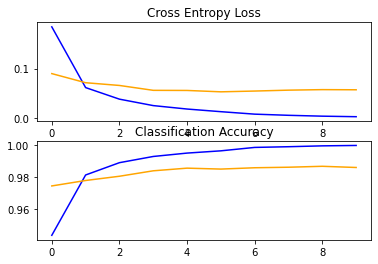

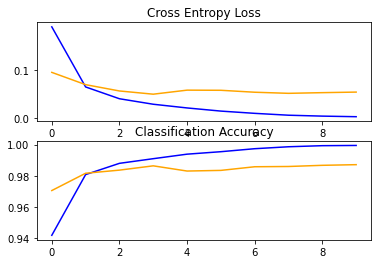

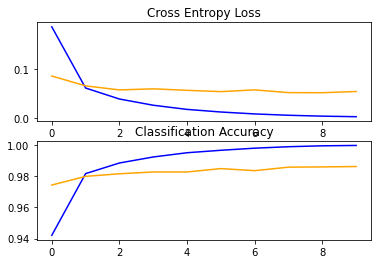

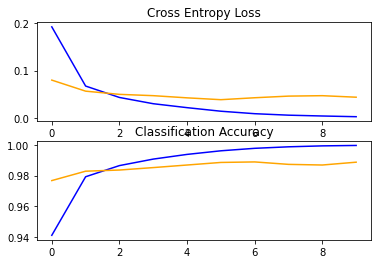

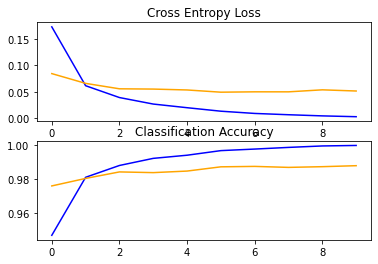

Accuracy: mean=98.717 std=0.100, n=5


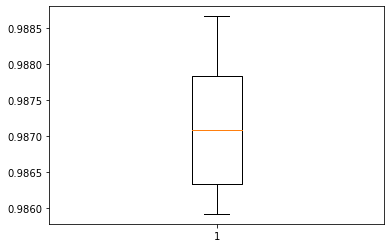

In [10]:
# entry point, run the test harness
run_test_harness()

In [11]:
# run the test harness for evaluating a model
def run_test_harness2():
  # load dataset
  trainX, trainY, testX, testY = load_dataset()

  # prepare pixel data
  trainX, testX = prep_pixels(trainX, testX)
  # define model
  model = define_model()

  # fit model
  model.fit(trainX, trainY, epochs=10, batch_size=32, verbose=0)

  # save model
  model.save('final_model.h5')

In [12]:
run_test_harness2()

/home/azel/.local/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:99: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(


60
./test/1_6.png


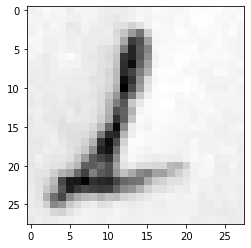

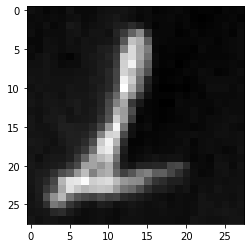

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
8
./test/5_2.png


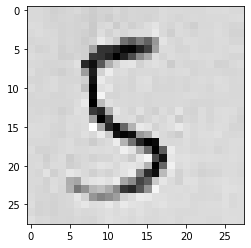

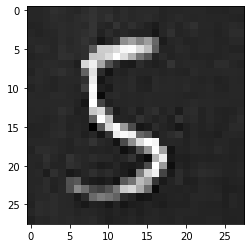

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
8
./test/3_3.png


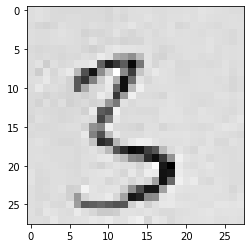

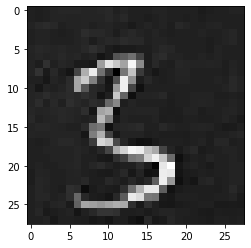

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
3
./test/2_6.png


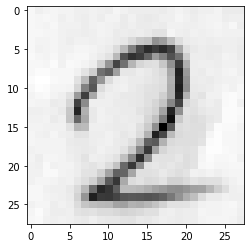

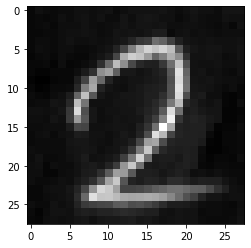

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
2
./test/8_4.png


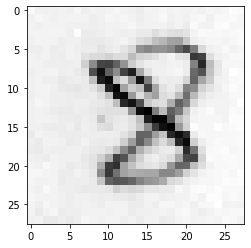

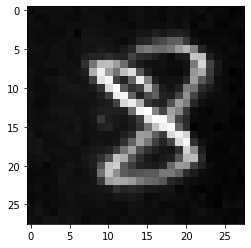

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
8
./test/1_3.png


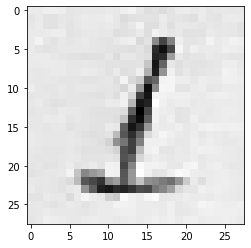

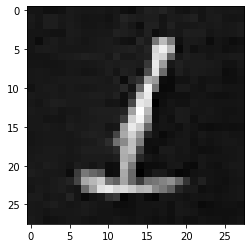

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1
./test/1_5.png


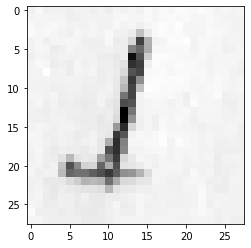

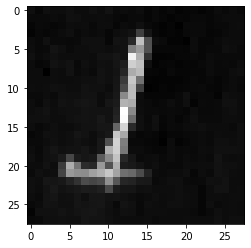

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1
./test/9_4.png


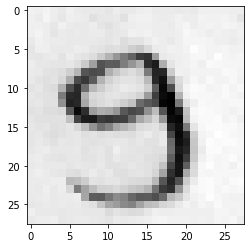

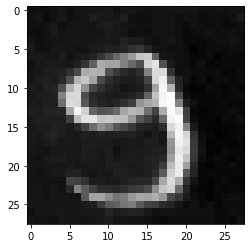

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
9
./test/0_2.png


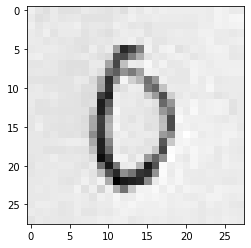

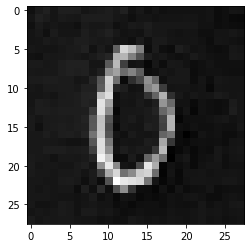

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
0
./test/4_3.png


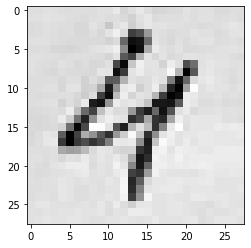

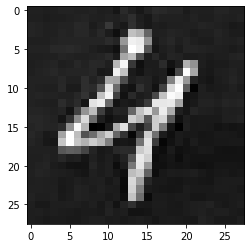

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
4
./test/9_3.png


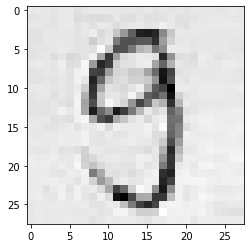

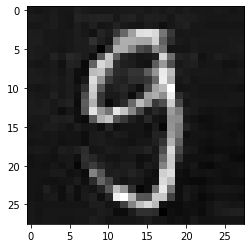

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
9
./test/8_3.png


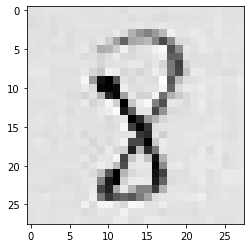

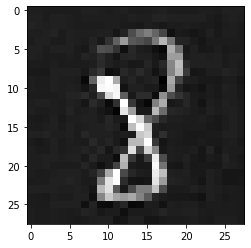

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
8
./test/3_2.png


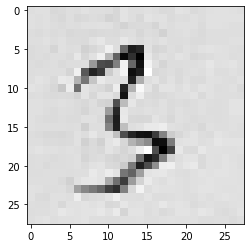

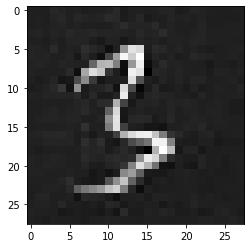

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
3
./test/5_4.png


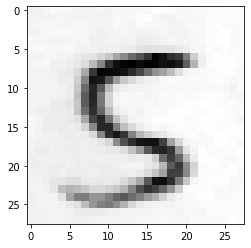

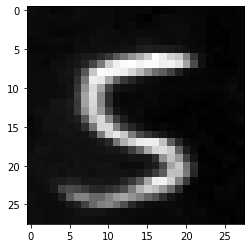

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
5
./test/5_1.png


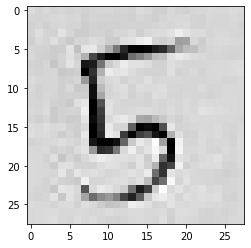

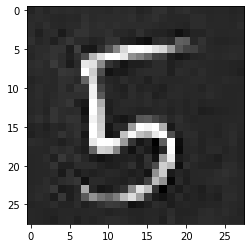

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
8
./test/5_6.png


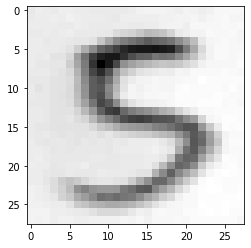

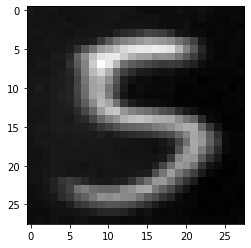

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
5
./test/0_4.png


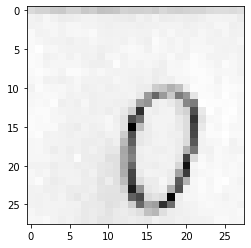

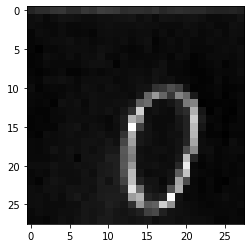

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
6
./test/7_5.png


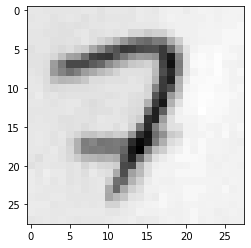

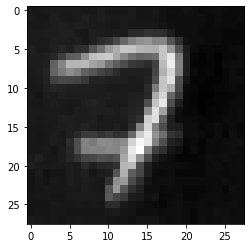

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
7
./test/3_1.png


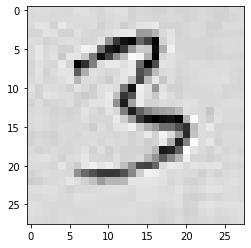

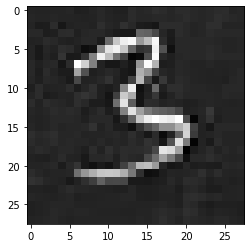

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
3
./test/7_6.png


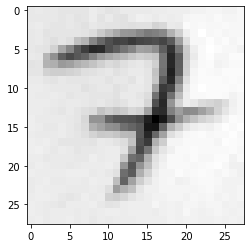

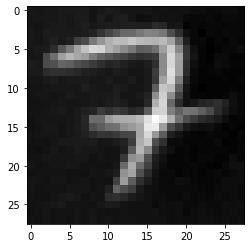

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
3
./test/2_4.png


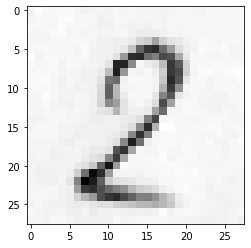

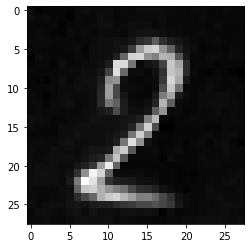

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
8
./test/3_6.png


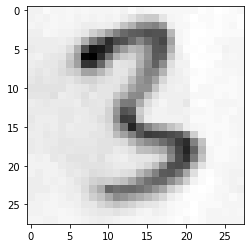

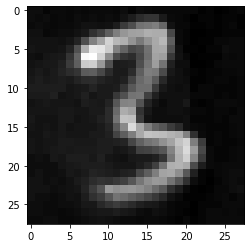

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
3
./test/9_5.png


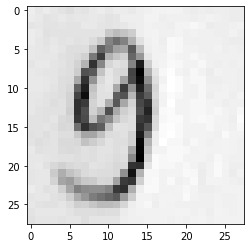

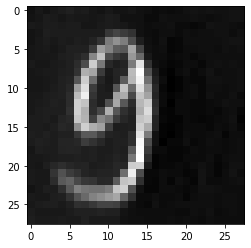

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
8
./test/6_5.png


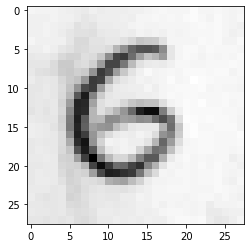

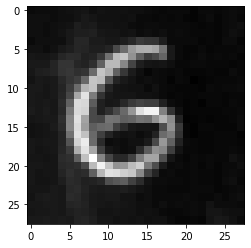

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
6
./test/8_2.png


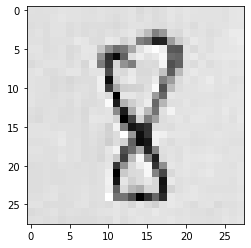

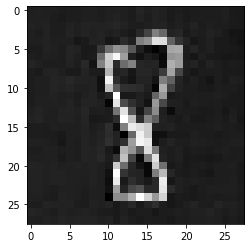

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
8
./test/4_1.png


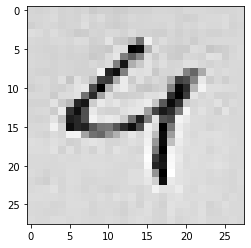

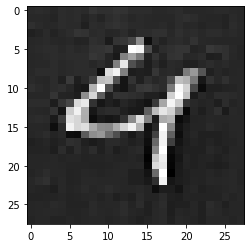

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
4
./test/3_5.png


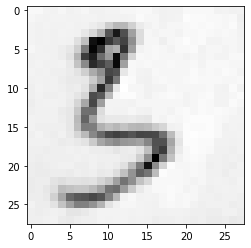

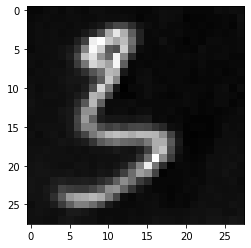

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
6
./test/2_1.png


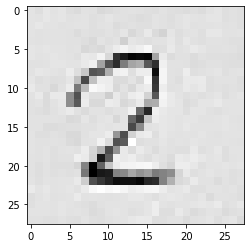

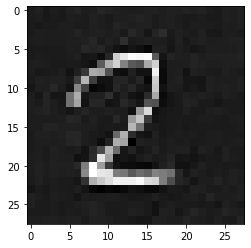

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
2
./test/8_1.png


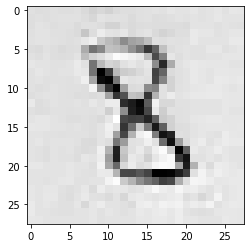

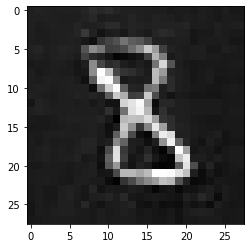

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
8
./test/7_4.png


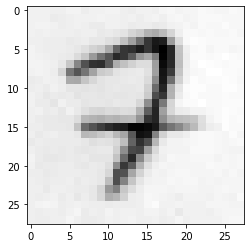

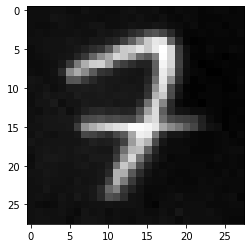

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
7
./test/1_2.png


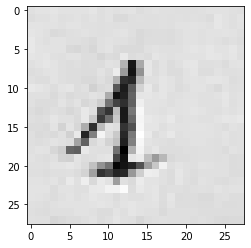

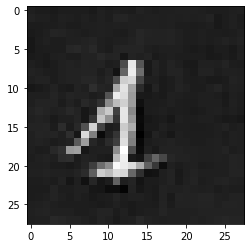

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
6
./test/4_2.png


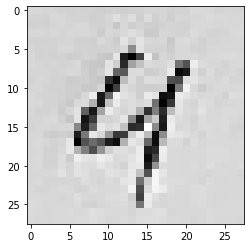

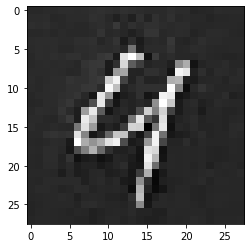

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
4
./test/4_4.png


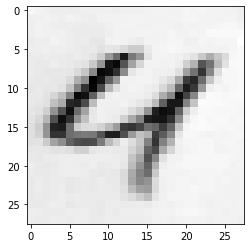

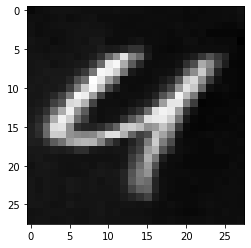

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
4
./test/6_6.png


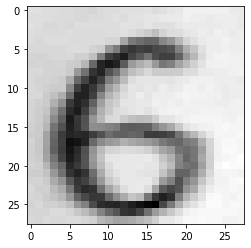

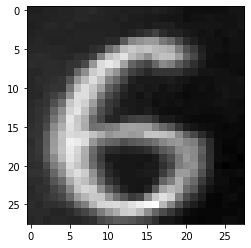

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
8
./test/9_1.png


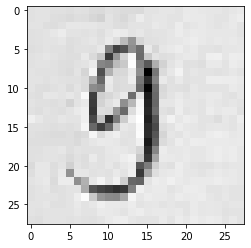

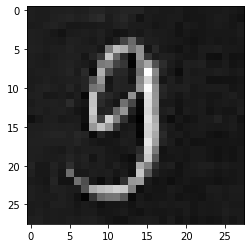

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
8
./test/0_3.png


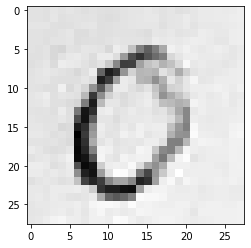

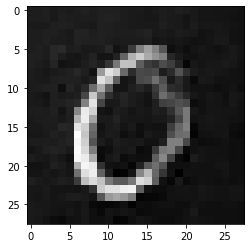

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
0
./test/0_1.png


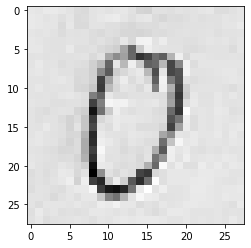

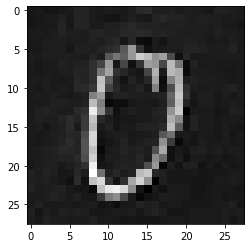

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
0
./test/4_5.png


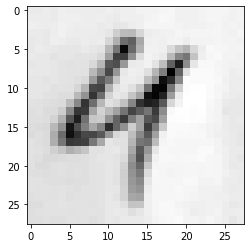

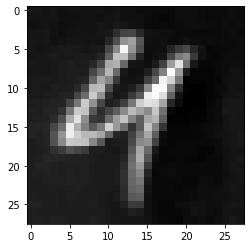

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
4
./test/6_1.png


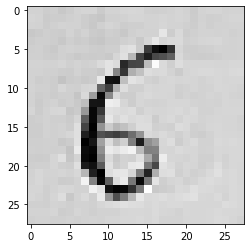

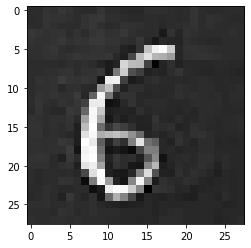

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
8
./test/8_6.png


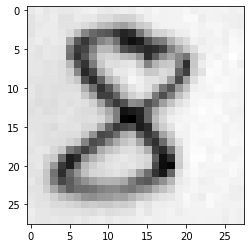

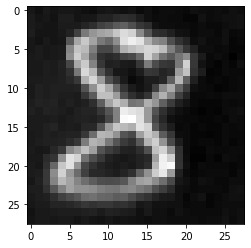

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
8
./test/9_6.png


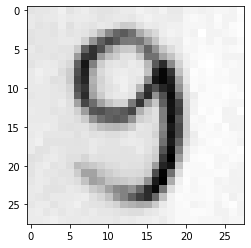

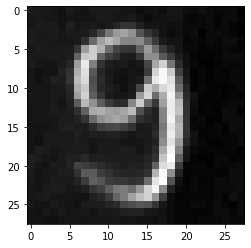

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
7
./test/9_2.png


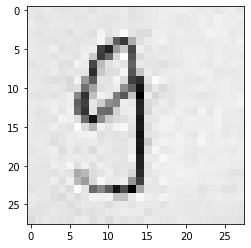

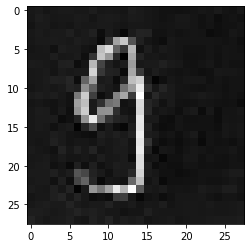

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
8
./test/2_3.png


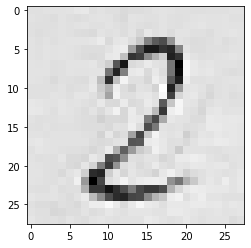

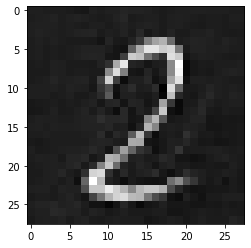

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
2
./test/1_4.png


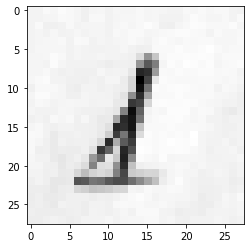

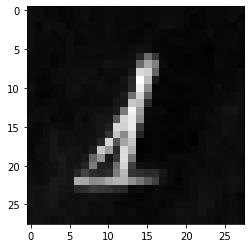

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1
./test/0_5.png


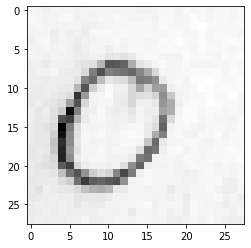

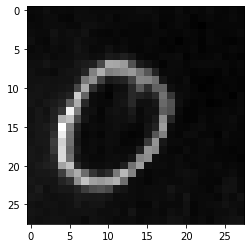

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
0
./test/5_5.png


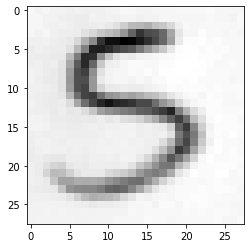

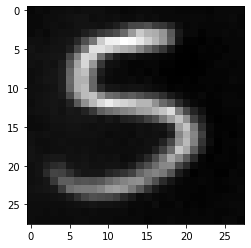

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
5
./test/1_1.png


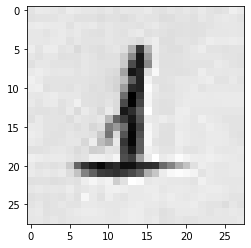

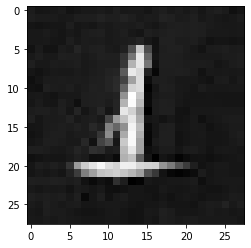

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
1
./test/0_6.png


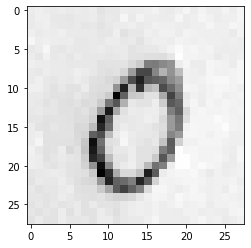

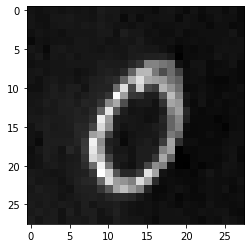

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
0
./test/6_2.png


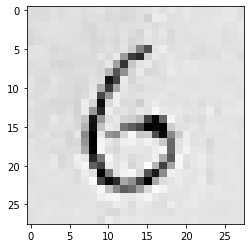

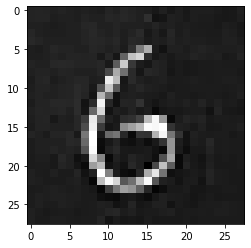

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
6
./test/5_3.png


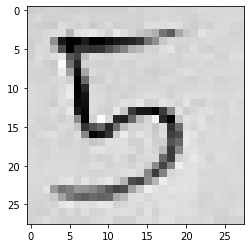

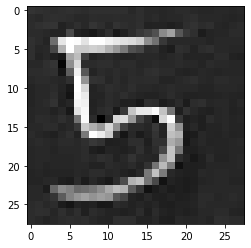

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
6
./test/2_2.png


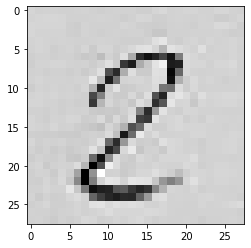

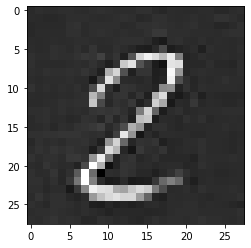

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
8
./test/4_6.png


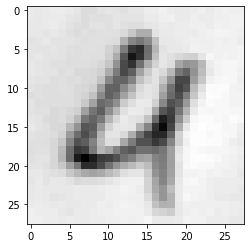

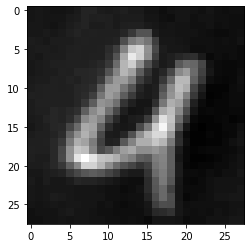

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
2
./test/3_4.png


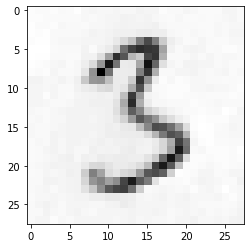

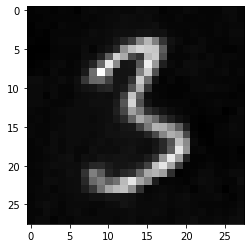

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
3
./test/7_1.png


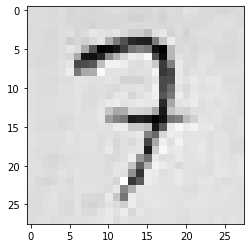

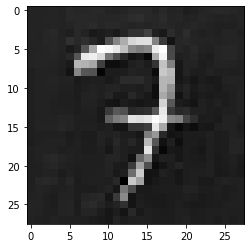

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
3
./test/7_2.png


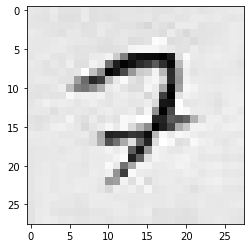

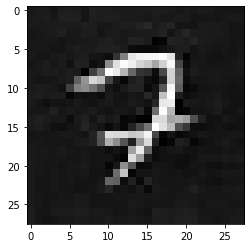

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
7
./test/8_5.png


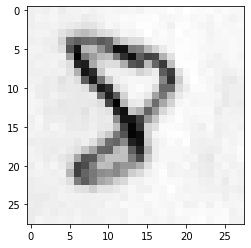

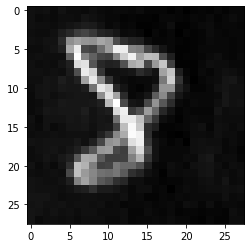

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
8
./test/7_3.png


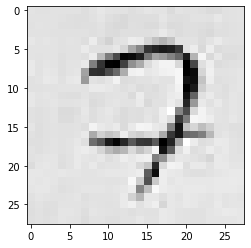

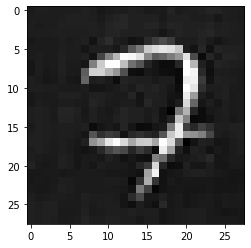

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
2
./test/6_3.png


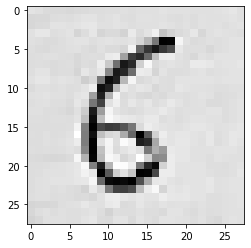

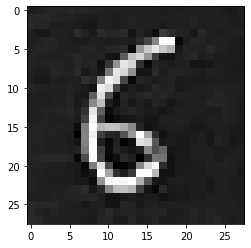

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
6
./test/2_5.png


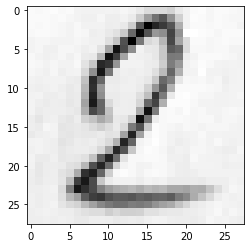

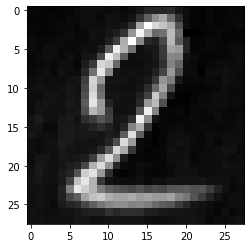

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
8
./test/6_4.png


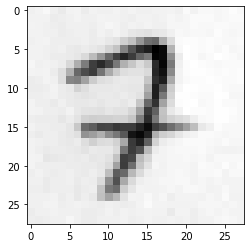

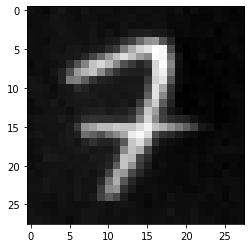

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
7


In [17]:
import glob
import tensorflow as tf

def load_image(filename):
    # load the image
    img = load_img(filename, color_mode="grayscale", target_size=(28, 28)) 
    
    plt.imshow(img, cmap=plt.get_cmap('gray'))
    plt.show()
    
    # convert to array
    img = img_to_array(img)

    # reshape into a single sample with 1 channel
    img = img.reshape(1, 28, 28, 1)
    
    # prepare pixel data
    img = img.astype('float32')

    
    # inverted color
    img = 255.0 - img 
    
    plt.imshow(img.reshape(28,28), cmap=plt.get_cmap('gray'))
    plt.show()
    
    img = img / 255.0
    
    return img

def run_example():
    c = 0
    listpath = glob.glob('./test/*')
    print(len(listpath))
    model = load_model('final_model.h5')
    # load the image
    for imagepath in listpath:
        print(imagepath)
        img = load_image(imagepath)
        predict_value = model.predict(img)
        digit = argmax(predict_value)
        print(digit)
        if str(digit) == imagepath[7]:
            c += 1
    return c/len(listpath)


c = run_example()

In [18]:
print("Accuracy: " + str(c))

Accuracy: 0.65
